## Research Question
## Can NFL team statistics predict how many points a team will score in its next game?

## Problem Definition

The purpose of this project is to determine whether NFL team statistics can be used to predict how many points a team will score in its next game. The target variable will be the total number of points scored by a team in its next game. Because the target is a numerical value, this is a regression problem.

This type of prediction could be useful for fantasy football players and sports bettors. Fantasy football players could use scoring predictions to help evaluate players and matchups, while sports bettors could use the model to better understand how strong an offense may perform in an upcoming game.

This problem is worth investigating because NFL scoring can depend on many different team statistics. By building a machine-learning model, I can test which statistics are most strongly related to future scoring and determine how accurately a team’s next-game point total can be predicted.

## Background and Context
Sports bettors often use team statistics and past performance to help predict whether an NFL game will go over or under the projected point total. Research has shown that previous team performance, offensive and defensive statistics, and betting market information can all be useful when predicting NFL scores (Baker & McHale, 2013). Other research has also found that sportsbook totals are generally strong estimates of how many points will be scored in a game (Dmochowski, 2023). Machine-learning projects have also used statistics such as offensive yards, defensive yards allowed, weather, and betting lines to predict NFL over/under results (Lukasik & Jenks, n.d.). These ideas support using team statistics to predict how many points an NFL team may score in its next game.

Baker, R. D., & McHale, I. G. (2013). Forecasting exact scores in National Football League games. International Journal of Forecasting, 29(1), 122–130. https://doi.org/10.1016/j.ijforecast.2012.07.002 ScienceDirect

Dmochowski, J. P. (2023). A statistical theory of optimal decision-making in sports betting. PLOS ONE, 18(6), e0287601. https://doi.org/10.1371/journal.pone.0287601 PLOS

Lukasik, J., & Jenks, M. (n.d.). NFL over/under prediction using machine learning in R [GitHub repository]. GitHub. https://github.com/jake-lukasik/NFL-OU-Models

## Data Description

For this project I used NFL team stats from nflverse with the nflreadpy package in Python, using data from the 2022, 2023, 2024, and 2025 seasons. Each row represents one team in one game, so each game shows up twice, once for each team. My target variable is next_game_points, which is how many points a team scores in its next game. I made that by sorting the data by team, season, and week and then shifting the score forward one game. The dataset had a lot of stats I could use like passing yards, rushing yards, touchdowns, interceptions, sacks, EPA, field goals, and points allowed. After looking through the data, I focused mostly on average passing EPA, average passing yards, average rushing yards, passing touchdowns, and the next opponent’s average points allowed. One issue was that there was no simple total score column, so I had to make one using touchdowns, field goals, extra points, two-point conversions, and safeties. Some rows also had missing values because the last game of the season does not have a next game to predict.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import nflreadpy as nfl

team_stats = nfl.load_team_stats([2022, 2023, 2024, 2025])

df = team_stats.to_pandas()

print(df.head())
print(df.columns)

   season  week team season_type          game_id opponent_team  completions  \
0    2022     1  ARI         REG   2022_01_KC_ARI            KC           24   
1    2022     1  ATL         REG   2022_01_NO_ATL            NO           20   
2    2022     1  BAL         REG  2022_01_BAL_NYJ           NYJ           17   
3    2022     1  BUF         REG   2022_01_BUF_LA            LA           26   
4    2022     1  CAR         REG  2022_01_CLE_CAR           CLE           16   

   attempts  passing_yards  passing_tds  ...  pt_yards  pt_inside_20  \
0        38            205            2  ...       255             0   
1        33            215            0  ...       180             2   
2        30            213            3  ...       291             3   
3        31            297            3  ...         0             0   
4        27            235            1  ...       250             0   

   pt_out_of_bounds  pt_downed  pt_touchback  pt_fair_caught  pt_returned  \
0        

In [3]:
print(df.columns.tolist())

['season', 'week', 'team', 'season_type', 'game_id', 'opponent_team', 'completions', 'attempts', 'passing_yards', 'passing_tds', 'passing_interceptions', 'sacks_suffered', 'sack_yards_lost', 'sack_fumbles', 'sack_fumbles_lost', 'passing_air_yards', 'passing_yards_after_catch', 'passing_first_downs', 'passing_epa', 'passing_cpoe', 'passing_2pt_conversions', 'passing_10', 'passing_16', 'passing_20', 'passing_40', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_fumbles', 'rushing_fumbles_lost', 'rushing_first_downs', 'rushing_epa', 'rushing_2pt_conversions', 'rushing_10', 'rushing_12', 'rushing_20', 'rushing_40', 'receptions', 'targets', 'receiving_yards', 'receiving_tds', 'receiving_fumbles', 'receiving_fumbles_lost', 'receiving_air_yards', 'receiving_yards_after_catch', 'receiving_first_downs', 'receiving_epa', 'receiving_2pt_conversions', 'receiving_10', 'receiving_16', 'receiving_20', 'receiving_40', 'special_teams_tds', 'def_tackles_solo', 'def_tackles_with_assist', 'def_tackle_a

In [4]:
print(df.shape)

(2278, 138)


In [43]:
print(df.isnull().sum())

season                         0
week                           0
team                           0
season_type                    0
game_id                        0
                            ... 
avg_rushing_tds              128
avg_passing_interceptions    128
avg_sacks_suffered           128
avg_passing_epa              128
avg_rushing_epa              128
Length: 155, dtype: int64


In [44]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])
print(df.isnull().sum().sum())

fg_long                          375
fg_pct                           263
fg_made_list                     375
fg_missed_list                  1766
fg_blocked_list                 2189
pat_pct                          224
pt_long                           42
next_game_points                 128
next_game_week                   128
avg_offensive_points_allowed     128
next_opponent                    128
next_opp_avg_points_allowed      128
avg_passing_yards                128
avg_rushing_yards                128
avg_passing_tds                  128
avg_rushing_tds                  128
avg_passing_interceptions        128
avg_sacks_suffered               128
avg_passing_epa                  128
avg_rushing_epa                  128
dtype: int64
6898


There is a lot of missing data but with math we can see that the 128 missing values from the averages are bacause of the last game of the season and all of the other data we are missing we don't use.

The dataset doesn't have a total score variable so I went into the data and found all the scoring variables and created a function to add them up and create a total score variable. "score"

In [5]:
def calculate_score(row):

    score = 0

    score += row["passing_tds"] * 6
    score += row["rushing_tds"] * 6
    score += row["def_tds"] * 6
    score += row["fumble_recovery_tds"] * 6
    score += row["special_teams_tds"] * 6

    score += row["fg_made"] * 3
    score += row["pat_made"]

    score += row["passing_2pt_conversions"] * 2
    score += row["rushing_2pt_conversions"] * 2
    score += row["def_2pt_made"] * 2

    score += row["def_safeties"] * 2

    return score

In [6]:
df["score"] = df.apply(calculate_score, axis=1)

To distinguish how strong the offense was I created a function to only add up all the offensive scores. "offense_points"

In [7]:
def calculate_offensive_points(row):

    offensive_points = 0

    # Offensive touchdowns
    offensive_points += row["passing_tds"] * 6
    offensive_points += row["rushing_tds"] * 6

    # Special teams touchdowns
    offensive_points += row["special_teams_tds"] * 6

    # Field goals
    offensive_points += row["fg_made"] * 3

    # Extra points
    offensive_points += row["pat_made"]

    # Offensive 2-point conversions
    offensive_points += row["passing_2pt_conversions"] * 2
    offensive_points += row["rushing_2pt_conversions"] * 2

    return offensive_points

In [8]:
df["offensive_points"] = df.apply(
    calculate_offensive_points,
    axis=1
)

I created a function to give me the amount of points the teams defense was being scored on a created the variable for the opponent's score. "opponent_score"

In [9]:
df = df.sort_values(["team", "season", "week"])

df["next_game_points"] = (
    df.groupby(["team", "season"])["score"]
    .shift(-1)
)

df["next_game_week"] = (
    df.groupby(["team", "season"])["week"]
    .shift(-1)
)

In [10]:
def add_points_allowed(df):

    opponent_scores = df[
        ["season", "week", "team", "score"]
    ].copy()

    opponent_scores = opponent_scores.rename(
        columns={
            "team": "opponent_team",
            "score": "points_allowed"
        }
    )

    df = df.merge(
        opponent_scores,
        on=["season", "week", "opponent_team"],
        how="left"
    )

    return df

In [11]:
df = add_points_allowed(df)

To accurately determine the strength of a team's offense I created the variable, "offensive_points_allowed", to show only the points the team's offense and special teams score and took out defensive scores. 

In [12]:
def add_offensive_points_allowed(df):

    opponent_points = df[
        ["season", "week", "team", "offensive_points"]
    ].copy()

    opponent_points = opponent_points.rename(
        columns={
            "team": "opponent_team",
            "offensive_points": "offensive_points_allowed"
        }
    )

    df = df.merge(
        opponent_points,
        on=["season", "week", "opponent_team"],
        how="left"
    )

    return df

In [13]:
df = add_offensive_points_allowed(df)

I made a function for the variable, "next_opp_avg_points_allowed", which represents how many offensive points the team’s next opponent has allowed on average so far that season.

In [14]:
def add_next_opponent_avg_points_allowed(df):

    df = df.sort_values(["team", "season", "week"]).copy()

    df["avg_offensive_points_allowed"] = (
        df.groupby(["team", "season"])["offensive_points_allowed"]
        .transform(lambda x: x.expanding().mean().shift(1))
    )

    df["next_opponent"] = (
        df.groupby(["team", "season"])["opponent_team"]
        .shift(-1)
    )

    df["next_game_week"] = (
        df.groupby(["team", "season"])["week"]
        .shift(-1)
    )

    defense_avg = df[
        [
            "season",
            "week",
            "team",
            "avg_offensive_points_allowed"
        ]
    ].copy()

    defense_avg = defense_avg.rename(
        columns={
            "team": "next_opponent",
            "week": "next_game_week",
            "avg_offensive_points_allowed":
                "next_opp_avg_points_allowed"
        }
    )

    df = df.merge(
        defense_avg,
        on=[
            "season",
            "next_game_week",
            "next_opponent"
        ],
        how="left"
    )

    return df

In [15]:
df = add_next_opponent_avg_points_allowed(df)

Checking to make sure the variables are correctly in the dataframe. 

In [16]:
print(
    df[
        [
            "season",
            "week",
            "team",
            "opponent_team",
            "score",
            "offensive_points",
            "points_allowed",
            "offensive_points_allowed"
        ]
    ].head(20)
)

    season  week team opponent_team  score  offensive_points  points_allowed  \
0     2022     1  ARI            KC     21                21              44   
1     2022     2  ARI            LV     29                23              23   
2     2022     3  ARI            LA     12                12              20   
3     2022     4  ARI           CAR     26                26              16   
4     2022     5  ARI           PHI     17                17              20   
5     2022     6  ARI           SEA      9                 3              19   
6     2022     7  ARI            NO     42                30              34   
7     2022     8  ARI           MIN     26                26              34   
8     2022     9  ARI           SEA     21                15              31   
9     2022    10  ARI            LA     27                27              17   
10    2022    11  ARI            SF     10                10              38   
11    2022    12  ARI           LAC     

Creating a heat map to compare the correlation of all the variables I might look at. 

In [17]:
variables = [
    "passing_yards",
    "rushing_yards",
    "passing_tds",
    "rushing_tds",
    "passing_interceptions",
    "sacks_suffered",
    "passing_first_downs",
    "rushing_first_downs",
    "passing_epa",
    "rushing_epa",
    "def_sacks",
    "def_interceptions",
    "def_pass_defended",
    "def_tackles_for_loss",
    "def_tds",
    "next_game_points"
]

In [18]:
correlation = df[variables].corr()

print(
    correlation["next_game_points"]
    .sort_values(ascending=False)
)

next_game_points         1.000000
passing_epa              0.147968
rushing_tds              0.088668
passing_tds              0.085540
passing_first_downs      0.083903
passing_yards            0.071003
rushing_yards            0.066223
rushing_first_downs      0.061144
def_interceptions        0.054834
rushing_epa              0.050450
def_sacks                0.025519
def_pass_defended        0.014768
def_tackles_for_loss     0.013188
def_tds                 -0.015744
passing_interceptions   -0.046801
sacks_suffered          -0.074974
Name: next_game_points, dtype: float64


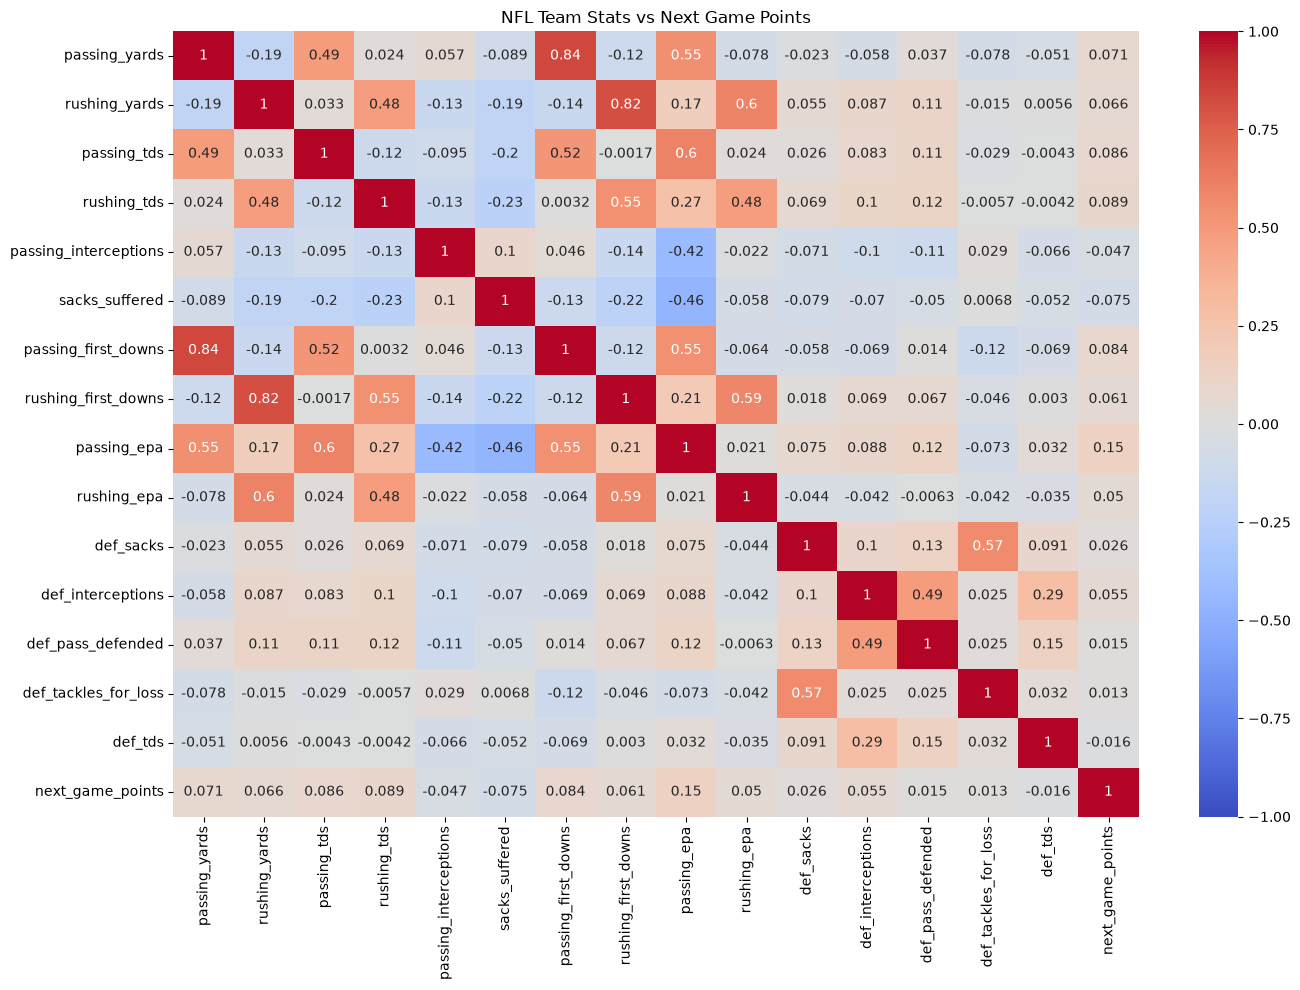

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("NFL Team Stats vs Next Game Points")
plt.tight_layout()
plt.show()

Finding the averages of the team's variables for each week and creating a up to date variable for each week

In [20]:
df = df.sort_values(["team", "season", "week"]).copy()

offensive_avg_vars = [
    "passing_yards",
    "rushing_yards",
    "passing_tds",
    "rushing_tds",
    "passing_interceptions",
    "sacks_suffered",
    "passing_epa",
    "rushing_epa"
]

for col in offensive_avg_vars:
    df[f"avg_{col}"] = (
        df.groupby(["team", "season"])[col]
        .transform(lambda x: x.expanding().mean().shift(1))
    )

Creating a heat map using the weekly averages

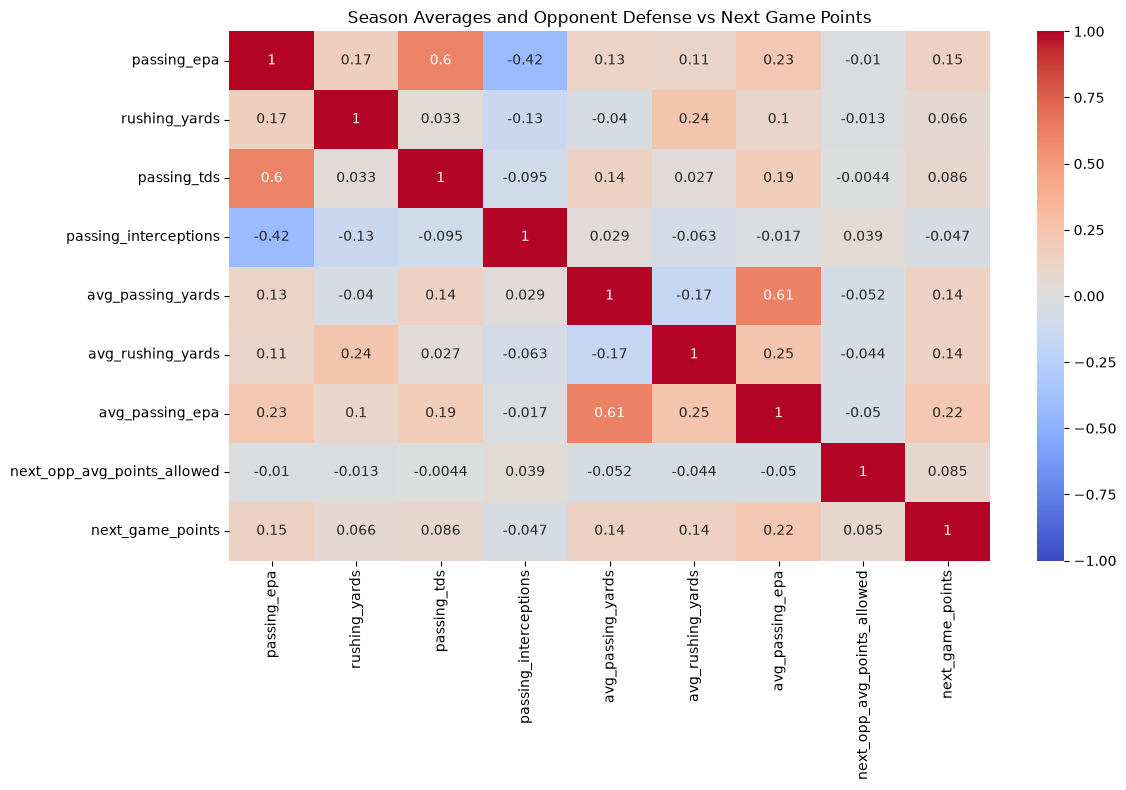

In [21]:
new_variables = [
    "passing_epa",
    "rushing_yards",
    "passing_tds",
    "passing_interceptions",
    "avg_passing_yards",
    "avg_rushing_yards",
    "avg_passing_epa",
    "next_opp_avg_points_allowed",
    "next_game_points"
]

new_corr = df[new_variables].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    new_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Season Averages and Opponent Defense vs Next Game Points")
plt.tight_layout()
plt.show()


After analyzing the two heat maps we put the following variables as candidates in our models: avg_passing_epa, avg_passing_yards, avg_rushing_yards, passing_tds, and next_opp_avg_points_allowed
We choose these variables because of the high correlation to next_game_points


## Baseline
Creating the baseline test by comparing each week's score and comparing that to estimate the next weeks score.

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def baseline_week_by_week(df):

    results = []

    data = df.sort_values(
        ["team", "season", "week"]
    ).copy()

    data["baseline_prediction"] = (
        data.groupby(["team", "season"])["score"]
        .transform(
            lambda x: x.expanding().mean().shift(1)
        )
    )

    test_data = data.dropna(
        subset=[
            "baseline_prediction",
            "next_game_points",
            "next_game_week"
        ]
    )

    for i in range(len(test_data)):

        projected = test_data.iloc[i]["baseline_prediction"]
        actual = test_data.iloc[i]["next_game_points"]

        results.append({
            "season": test_data.iloc[i]["season"],
            "stats_week": test_data.iloc[i]["week"],
            "game_week": int(
                test_data.iloc[i]["next_game_week"]
            ),
            "team": test_data.iloc[i]["team"],
            "projected_points": round(projected, 2),
            "actual_points": actual,
            "error": round(
                projected - actual,
                2
            ),
            "absolute_error": round(
                abs(projected - actual),
                2
            )
        })

    return pd.DataFrame(results)

In [23]:
baseline_results = baseline_week_by_week(df)

print(baseline_results.head(20))

    season  stats_week  game_week team  projected_points  actual_points  \
0     2022           2          3  ARI             21.00           12.0   
1     2022           3          4  ARI             25.00           26.0   
2     2022           4          5  ARI             20.67           17.0   
3     2022           5          6  ARI             22.00            9.0   
4     2022           6          7  ARI             21.00           42.0   
5     2022           7          8  ARI             19.00           26.0   
6     2022           8          9  ARI             22.29           21.0   
7     2022           9         10  ARI             22.75           27.0   
8     2022          10         11  ARI             22.56           10.0   
9     2022          11         12  ARI             23.00           24.0   
10    2022          12         14  ARI             21.82           13.0   
11    2022          14         15  ARI             22.00           15.0   
12    2022          15   

In [24]:
baseline_mae = mean_absolute_error(
    baseline_results["actual_points"],
    baseline_results["projected_points"]
)

baseline_rmse = mean_squared_error(
    baseline_results["actual_points"],
    baseline_results["projected_points"]
) ** 0.5

baseline_r2 = r2_score(
    baseline_results["actual_points"],
    baseline_results["projected_points"]
)

print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline R2:", round(baseline_r2, 3))

Baseline MAE: 7.93
Baseline RMSE: 10.07
Baseline R2: -0.04


## Baseline breakdown
The MAE being about 8 tells us the model was off by and average of 8 points. The RMSE tells us the model's misses were large, and the R2 being -.04 tells us the model is very innacurate.

## OLS
My linear regression machine learning program I will use is an OLS model to predict the team's next score.

In [25]:
ols_model2 = smf.ols(
    formula="""
    next_game_points ~
    avg_passing_epa +
    avg_passing_yards +
    avg_rushing_yards +
    passing_tds +
    next_opp_avg_points_allowed
    """,
    data=df
).fit()

print(ols_model2.summary())

                            OLS Regression Results                            
Dep. Variable:       next_game_points   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     33.14
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           1.35e-32
Time:                        22:40:33   Log-Likelihood:                -7419.9
No. Observations:                2022   AIC:                         1.485e+04
Df Residuals:                    2016   BIC:                         1.489e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

Creating a function so that the OLS model doesn't use future games to predict the score

In [26]:
def week_by_week_ols(df):

    results = []

    needed_columns = [
        "season",
        "week",
        "team",
        "next_game_week",
        "next_game_points",
        "avg_passing_epa",
        "avg_passing_yards",
        "avg_rushing_yards",
        "passing_tds",
        "next_opp_avg_points_allowed"
    ]

    model_data = df[
        needed_columns
    ].dropna().copy()

    model_data = model_data.sort_values(
        ["season", "week", "team"]
    )

    for season in sorted(model_data["season"].unique()):

        weeks = sorted(
            model_data[
                model_data["season"] == season
            ]["week"].unique()
        )

        for week in weeks:

            train = model_data[
                (model_data["season"] < season)
                |
                (
                    (model_data["season"] == season)
                    &
                    (model_data["week"] < week)
                )
            ]


            test = model_data[
                (model_data["season"] == season)
                &
                (model_data["week"] == week)
            ]

            if len(train) < 50 or len(test) == 0:
                continue

            model = smf.ols(
                formula="""
                next_game_points ~
                avg_passing_epa +
                avg_passing_yards +
                avg_rushing_yards +
                passing_tds +
                next_opp_avg_points_allowed
                """,
                data=train
            ).fit()

            predictions = model.predict(test)

            for i in range(len(test)):

                projected = predictions.iloc[i]
                actual = test.iloc[i]["next_game_points"]

                results.append({
                    "season": season,
                    "stats_week": week,
                    "game_week": int(
                        test.iloc[i]["next_game_week"]
                    ),
                    "team": test.iloc[i]["team"],
                    "projected_points": round(projected, 2),
                    "actual_points": actual,
                    "error": round(projected - actual, 2),
                    "absolute_error": round(
                        abs(projected - actual),
                        2
                    )
                })

    return pd.DataFrame(results)

In [27]:
ols_results = week_by_week_ols(df)

print(ols_results.head(30))

    season  stats_week  game_week team  projected_points  actual_points  \
0     2022           4          5  ARI             21.34           17.0   
1     2022           4          5  ATL             21.98           15.0   
2     2022           4          5  BAL             21.86           19.0   
3     2022           4          5  BUF             21.57           38.0   
4     2022           4          5  CAR             21.14           15.0   
5     2022           4          5  CHI             23.63           22.0   
6     2022           4          5  CIN             23.08           17.0   
7     2022           4          5  CLE             23.66           28.0   
8     2022           4          5  DAL             23.12           22.0   
9     2022           4          5  DEN             22.84            9.0   
10    2022           4          5  DET             24.30            0.0   
11    2022           4          5   GB             22.24           22.0   
12    2022           4   

In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

ols_mae = mean_absolute_error(
    ols_results["actual_points"],
    ols_results["projected_points"]
)

ols_rmse = mean_squared_error(
    ols_results["actual_points"],
    ols_results["projected_points"]
) ** 0.5

ols_r2 = r2_score(
    ols_results["actual_points"],
    ols_results["projected_points"]
)

print("OLS MAE:", round(ols_mae, 2))
print("OLS RMSE:", round(ols_rmse, 2))
print("OLS R2:", round(ols_r2, 3))

OLS MAE: 7.62
OLS RMSE: 9.57
OLS R2: 0.069


## OLS Breakdown
The MAE and RMSE both improve slightly by getting around .4 lower for each and the R2 improves a little by as well and the model is slightly more accurate because of that.

## Random Forest
Using the same variables from the OLS I will make a Random Forest model and compare the MAE, RMSE, and R2

In [29]:
from sklearn.ensemble import RandomForestRegressor
def week_by_week_random_forest(df):

    results = []

    features = [
        "avg_passing_epa",
        "avg_passing_yards",
        "avg_rushing_yards",
        "passing_tds",
        "next_opp_avg_points_allowed"
    ]

    needed_columns = [
        "season",
        "week",
        "team",
        "next_game_week",
        "next_game_points"
    ] + features

    model_data = df[
        needed_columns
    ].dropna().copy()

    model_data = model_data.sort_values(
        ["season", "week", "team"]
    )

    for season in sorted(model_data["season"].unique()):

        weeks = sorted(
            model_data[
                model_data["season"] == season
            ]["week"].unique()
        )

        for week in weeks:

            # Train only on games BEFORE this week
            train = model_data[
                (model_data["season"] < season)
                |
                (
                    (model_data["season"] == season)
                    &
                    (model_data["week"] < week)
                )
            ]

            # Use current week stats to predict next game
            test = model_data[
                (model_data["season"] == season)
                &
                (model_data["week"] == week)
            ]

            if len(train) < 50 or len(test) == 0:
                continue

            X_train = train[features]
            y_train = train["next_game_points"]

            X_test = test[features]

            model = RandomForestRegressor(
                n_estimators=200,
                max_depth=8,
                random_state=42
            )

            model.fit(X_train, y_train)

            predictions = model.predict(X_test)

            for i in range(len(test)):

                projected = predictions[i]
                actual = test.iloc[i]["next_game_points"]

                results.append({
                    "season": season,
                    "stats_week": week,
                    "game_week": int(
                        test.iloc[i]["next_game_week"]
                    ),
                    "team": test.iloc[i]["team"],
                    "projected_points": round(projected, 2),
                    "actual_points": actual,
                    "error": round(
                        projected - actual,
                        2
                    ),
                    "absolute_error": round(
                        abs(projected - actual),
                        2
                    )
                })

    return pd.DataFrame(results)

In [30]:
rf_results = week_by_week_random_forest(df)

print(rf_results.head(20))

    season  stats_week  game_week team  projected_points  actual_points  \
0     2022           4          5  ARI             21.76           17.0   
1     2022           4          5  ATL             20.29           15.0   
2     2022           4          5  BAL             20.90           19.0   
3     2022           4          5  BUF             17.98           38.0   
4     2022           4          5  CAR             15.08           15.0   
5     2022           4          5  CHI             24.95           22.0   
6     2022           4          5  CIN             24.42           17.0   
7     2022           4          5  CLE             26.56           28.0   
8     2022           4          5  DAL             26.27           22.0   
9     2022           4          5  DEN             25.54            9.0   
10    2022           4          5  DET             21.86            0.0   
11    2022           4          5   GB             23.95           22.0   
12    2022           4   

In [31]:
rf_mae = mean_absolute_error(
    rf_results["actual_points"],
    rf_results["projected_points"]
)

rf_rmse = mean_squared_error(
    rf_results["actual_points"],
    rf_results["projected_points"]
) ** 0.5

rf_r2 = r2_score(
    rf_results["actual_points"],
    rf_results["projected_points"]
)

print("Random Forest MAE:", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))
print("Random Forest R2:", round(rf_r2, 3))

Random Forest MAE: 7.72
Random Forest RMSE: 9.74
Random Forest R2: 0.036


## Random Forest Breakdown
While the MAE, RMSE, and R2 improve from the baseline they are still not as accurate as the OLS model

comparing the 3 models on how far off they were from the actual points

In [32]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "OLS2",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        ols_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        ols_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        ols_r2,
        rf_r2
    ]
})

print(model_comparison.round(3))

           Model    MAE    RMSE     R2
0       Baseline  7.934  10.072 -0.040
1           OLS2  7.623   9.575  0.069
2  Random Forest  7.725   9.742  0.036


## Visual
This is a bar graph comparing the RMSE and MAE together and another model to show the R2 because of how small the number is.

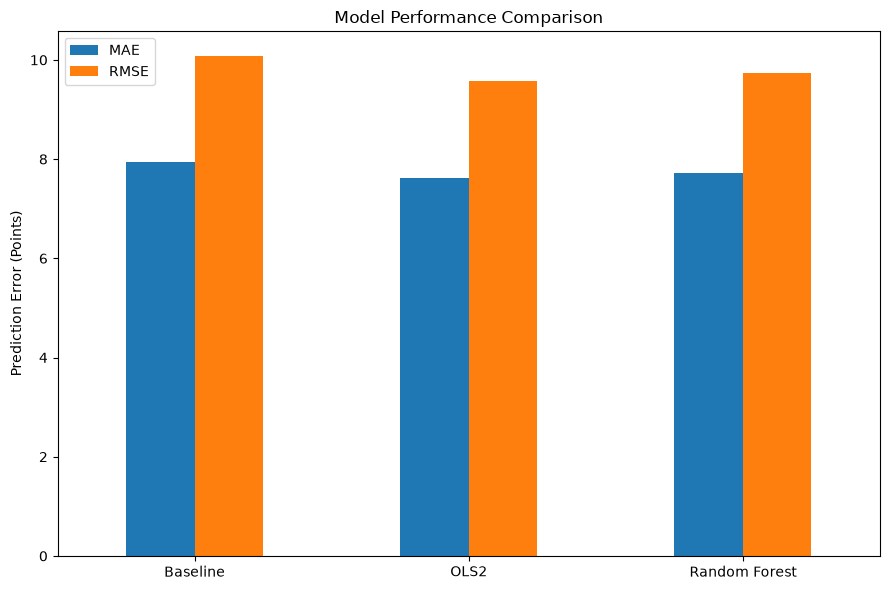

In [33]:
import matplotlib.pyplot as plt

model_comparison.plot(
    x="Model",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(9, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Prediction Error (Points)")
plt.xlabel("")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

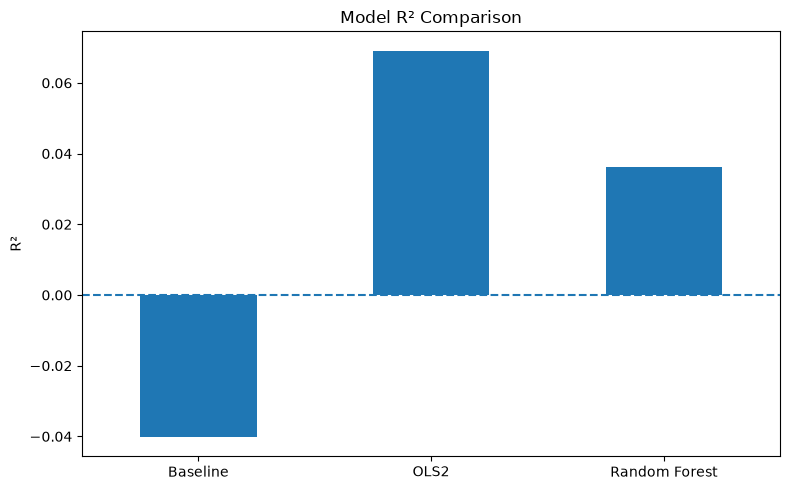

In [34]:
model_comparison.plot(
    x="Model",
    y="R2",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Model R² Comparison")
plt.ylabel("R²")
plt.xlabel("")
plt.axhline(0, linestyle="--")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Model Selection
The OLS model I built was the best model of the 3 choices we had.  The models all were inaccurate and had big misses but the OLS performed the best.

## Visual
This plot chart shows the predicted scores and actual scores of the last 500 games and 100 games in the OLS model.
We chose the OLS chart to graph the predictions because it performed the best and most accurate between the 3 models we created. 

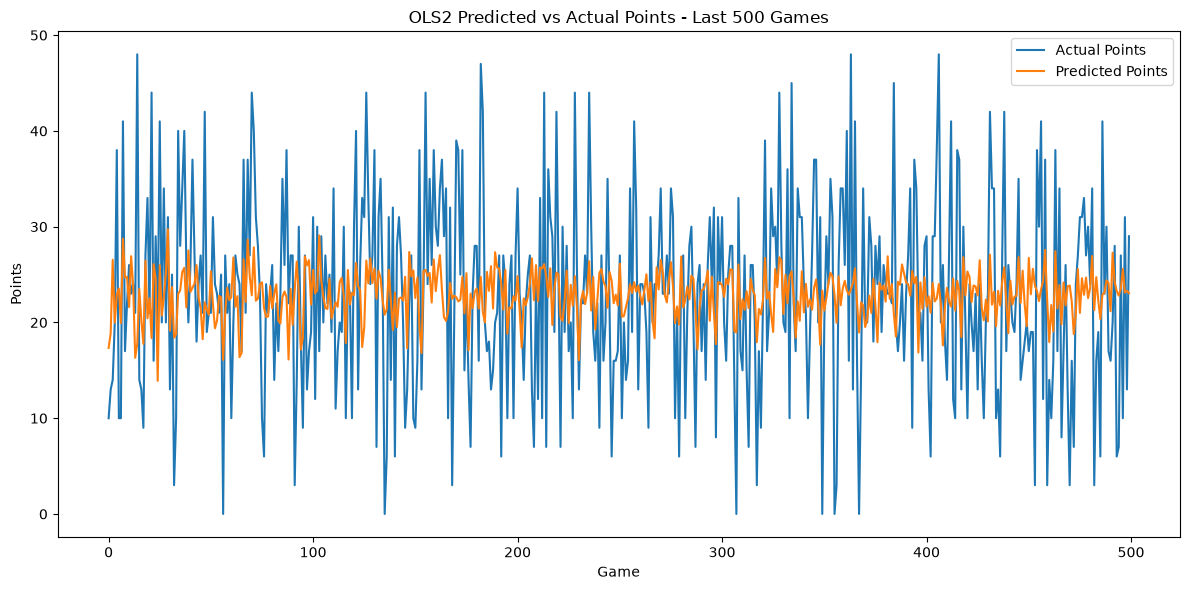

In [35]:

last_500 = ols_results.tail(500).copy()

plt.figure(figsize=(12,6))

plt.plot(
    last_500["actual_points"].values,
    label="Actual Points"
)

plt.plot(
    last_500["projected_points"].values,
    label="Predicted Points"
)

plt.title("OLS2 Predicted vs Actual Points - Last 500 Games")
plt.xlabel("Game")
plt.ylabel("Points")
plt.legend()

plt.tight_layout()
plt.show()

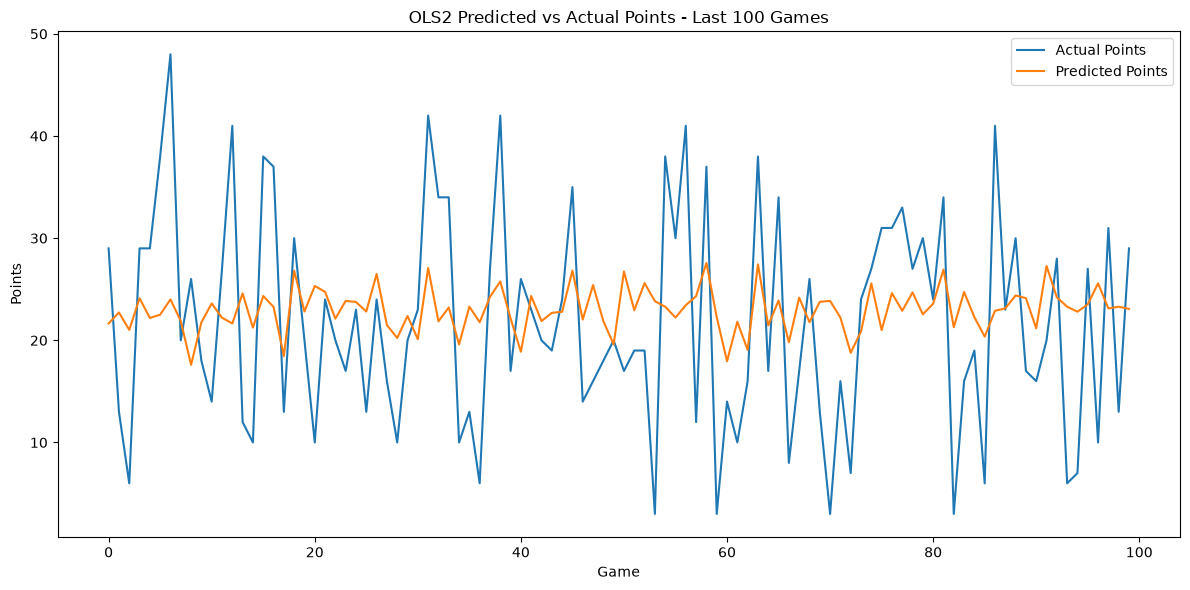

In [36]:
last_100 = ols_results.tail(100).copy()

plt.figure(figsize=(12,6))

plt.plot(
    last_100["actual_points"].values,
    label="Actual Points"
)

plt.plot(
    last_100["projected_points"].values,
    label="Predicted Points"
)

plt.title("OLS2 Predicted vs Actual Points - Last 100 Games")
plt.xlabel("Game")
plt.ylabel("Points")
plt.legend()

plt.tight_layout()
plt.show()

This shows the p values and coefficients of the variables we used in the OLS model.  All five variables had p-values below .05, meaning they had statistically significant relationships with next-game scoring. However, the model's low R² shows that NFL scoring is still difficult to predict accurately.

In [37]:
ols2_coefficients = pd.DataFrame({
    "Feature": ols_model2.params.index,
    "Coefficient": ols_model2.params.values,
    "P_Value": ols_model2.pvalues.values
})

print(ols2_coefficients.round(3))

                       Feature  Coefficient  P_Value
0                    Intercept        6.391    0.018
1              avg_passing_epa        0.246    0.000
2            avg_passing_yards        0.018    0.018
3            avg_rushing_yards        0.041    0.000
4                  passing_tds        0.436    0.022
5  next_opp_avg_points_allowed        0.293    0.000


In [38]:
from sklearn.ensemble import RandomForestRegressor

features = [
    "avg_passing_epa",
    "avg_passing_yards",
    "avg_rushing_yards",
    "passing_tds",
    "next_opp_avg_points_allowed"
]

rf_data = df[
    features + ["next_game_points"]
].dropna().copy()

X = rf_data[features]
y = rf_data["next_game_points"]

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

This shows the importance of each variable to next_score in order and showing the importance % between them.

In [39]:
rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print(rf_importance)

                       Feature  Importance
0              avg_passing_epa    0.326065
2            avg_rushing_yards    0.228316
4  next_opp_avg_points_allowed    0.208467
1            avg_passing_yards    0.191582
3                  passing_tds    0.045570


## Error Breakdown
I found the biggest errors from the OLS model and created a bar graph to show them.

In [40]:
opponent_lookup = df[
    ["season", "week", "team", "next_opponent"]
].copy()

opponent_lookup = opponent_lookup.rename(
    columns={"week": "stats_week"}
)

ols_results = ols_results.merge(
    opponent_lookup,
    on=["season", "stats_week", "team"],
    how="left"
)

In [41]:
biggest_misses = ols_results.sort_values(
    "absolute_error",
    ascending=False
).head(10)

print(
    biggest_misses[
        [
            "season",
            "game_week",
            "team",
            "next_opponent",
            "actual_points",
            "projected_points",
            "absolute_error"
        ]
    ]
)

      season  game_week team next_opponent  actual_points  projected_points  \
811     2023         15   LV           LAC           63.0             19.14   
459     2023          3  MIA           DEN           70.0             31.61   
858     2023         17  BAL           MIA           56.0             23.42   
240     2022         13  DAL           IND           54.0             22.09   
336     2022         16   LA           DEN           51.0             19.31   
1448    2024         21  PHI           WAS           55.0             24.62   
1472    2025          3  MIN           CIN           48.0             17.78   
1068    2024          6   TB            NO           51.0             21.70   
99      2022          8  DAL           CHI           49.0             20.72   
910     2023         18   NO           ATL           48.0             21.44   

      absolute_error  
811            43.86  
459            38.39  
858            32.58  
240            31.91  
336            

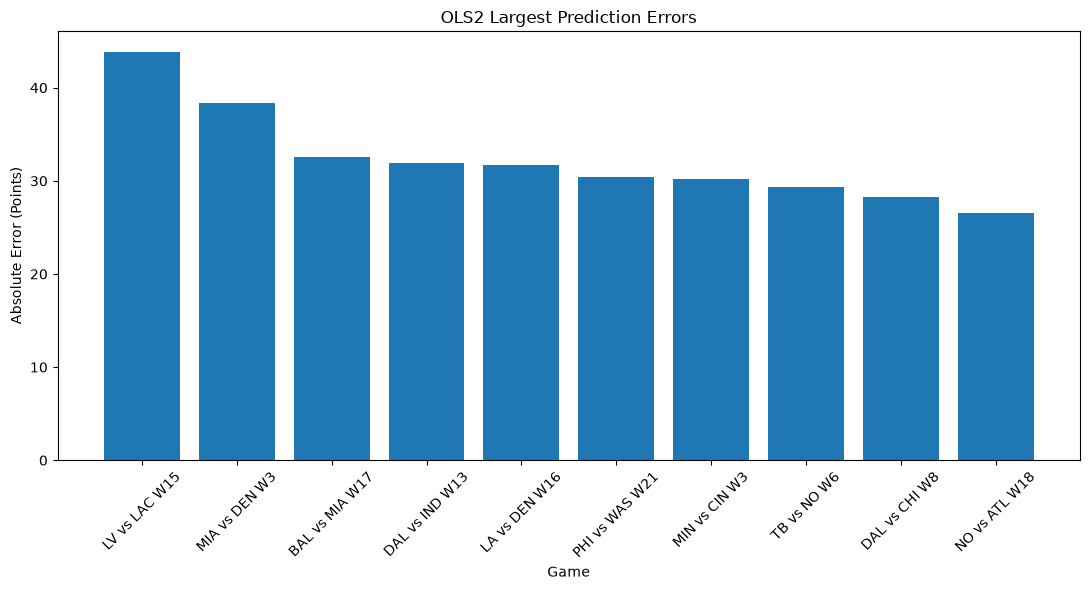

In [42]:
plt.figure(figsize=(11,6))

labels = (
    biggest_misses["team"]
    + " vs "
    + biggest_misses["next_opponent"]
    + " W"
    + biggest_misses["game_week"].astype(str)
)

plt.bar(
    labels,
    biggest_misses["absolute_error"]
)

plt.title("OLS2 Largest Prediction Errors")
plt.ylabel("Absolute Error (Points)")
plt.xlabel("Game")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# AI Usage
For this project I used Claude Sonnet 5.5, Claude helped me create a to-do list and help with coding errors. Before I turned in the project I went over and was able to communicate and explain what the code was doing. 
https://claude.ai/chat/1e1fd84e-5d7b-4fe7-8609-5354ce639e0344bbc

### Limitations and Reflection
One limitation of this model is that NFL games can be affected by things that are not included in the dataset, such as injuries, weather, home-field advantage, coaching changes, turnovers, and player availability. The low R² also shows that most of the differences in next-game scoring are still not explained by the variables in the model. Because sports bettors could use these predictions, it is important to understand that the model is not guaranteed to be accurate and should not be treated as betting advice. If I continued this project, I would add more variables such as weather, injuries, quarterback status, home or away games, and betting lines to see if the predictions improve.